## CONV2

### 1 CAPA

In [1]:
import os 
import numpy as np  
from PIL import Image  
import tensorflow as tf  
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense  # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping  # Importa el callback

2025-09-23 21:55:54.036243: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-23 21:55:54.492536: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-23 21:55:56.615556: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Redimensionar imágenes

In [5]:
# Directorio original y reducido
d_original = '/home/fisica/bandas/banda13/ene_01'
d_reducida = '/home/fisica/bandas/banda13/ene_01_reducida_test'


# Función de redimensionado - TAMAÑO PEQUEÑO PARA PRUEBAS
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))  # Redimensiona la imagen
            np.save(os.path.join(d_reducida, filename), img_resized)  # Guarda la imagen redimensionada

In [6]:
# Directorio de las nuevas imágenes 920x920 y su destino reducido
d_original_9 = '/home/fisica/bandas/banda9/ene_01'  # Cambia esta ruta por la ubicación real
d_reducida_9 = '/home/fisica/bandas/banda9/ene_01_reducida'  # Cambia esta ruta por el destino deseado

# Redimensionar las imágenes 920x920 a 480x480 usando la función existente
resize_npy_images(d_original_9, d_reducida_9, new_size=(480, 480))

# Cargar las 23 imágenes
file_list = sorted([f for f in os.listdir(d_reducida_9) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_9 = [np.load(os.path.join(d_reducida_9, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_9 = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_9]
images_9 = [np.clip(img, 0, 1) for img in images_9]  # Limita los valores al rango [0, 1]
X_1 = np.array(images_9[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_1 = np.array(images_9[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal


Procesando 23 imágenes


In [4]:
# Redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar las 23 imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

# Modelo secuencial simple
# model = Sequential([
#     Conv2D(8, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
#     Conv2D(4, (3, 3), activation='relu', padding='same'),
#     Conv2D(1, (3, 3), activation='linear', padding='same')
# ])

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (3, 3), activation='linear', padding='same')
])

# model = Sequential([
#     Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
#     Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
#     Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
#     Conv2D(1, kernel_size=(3, 3), activation='linear', padding='same')
# ])

model.compile(optimizer='adam', loss='mae', metrics=['mae'])

print("Resumen del modelo:")
model.summary()

# Entrenamiento rápido - solo 3 épocas
print("Iniciando entrenamiento de prueba...")

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X, y,
    epochs=50,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history.history['loss'][-1]:.4f}")

PermissionError: [Errno 13] Permission denied: '/media/smoke'

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step


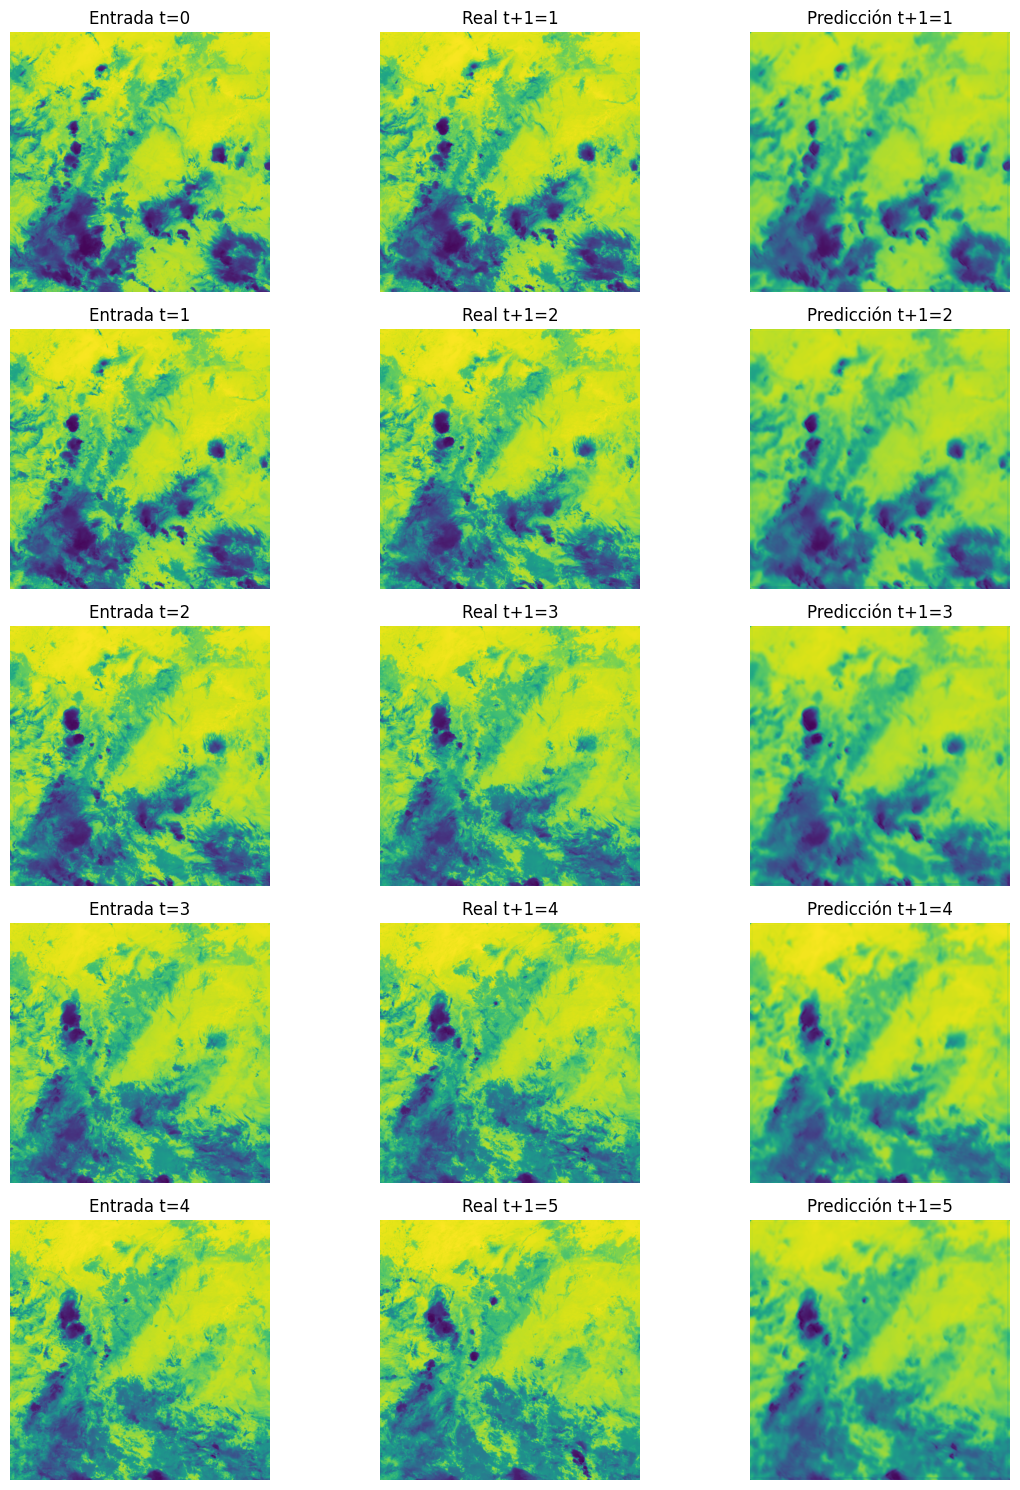

In [4]:
import matplotlib.pyplot as plt

# Selecciona el número de ejemplos a mostrar
n = 5

y_pred = model.predict(X)  # Genera las predicciones

# Muestra imágenes reales vs predichas usando un mapa de color
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='viridis')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step


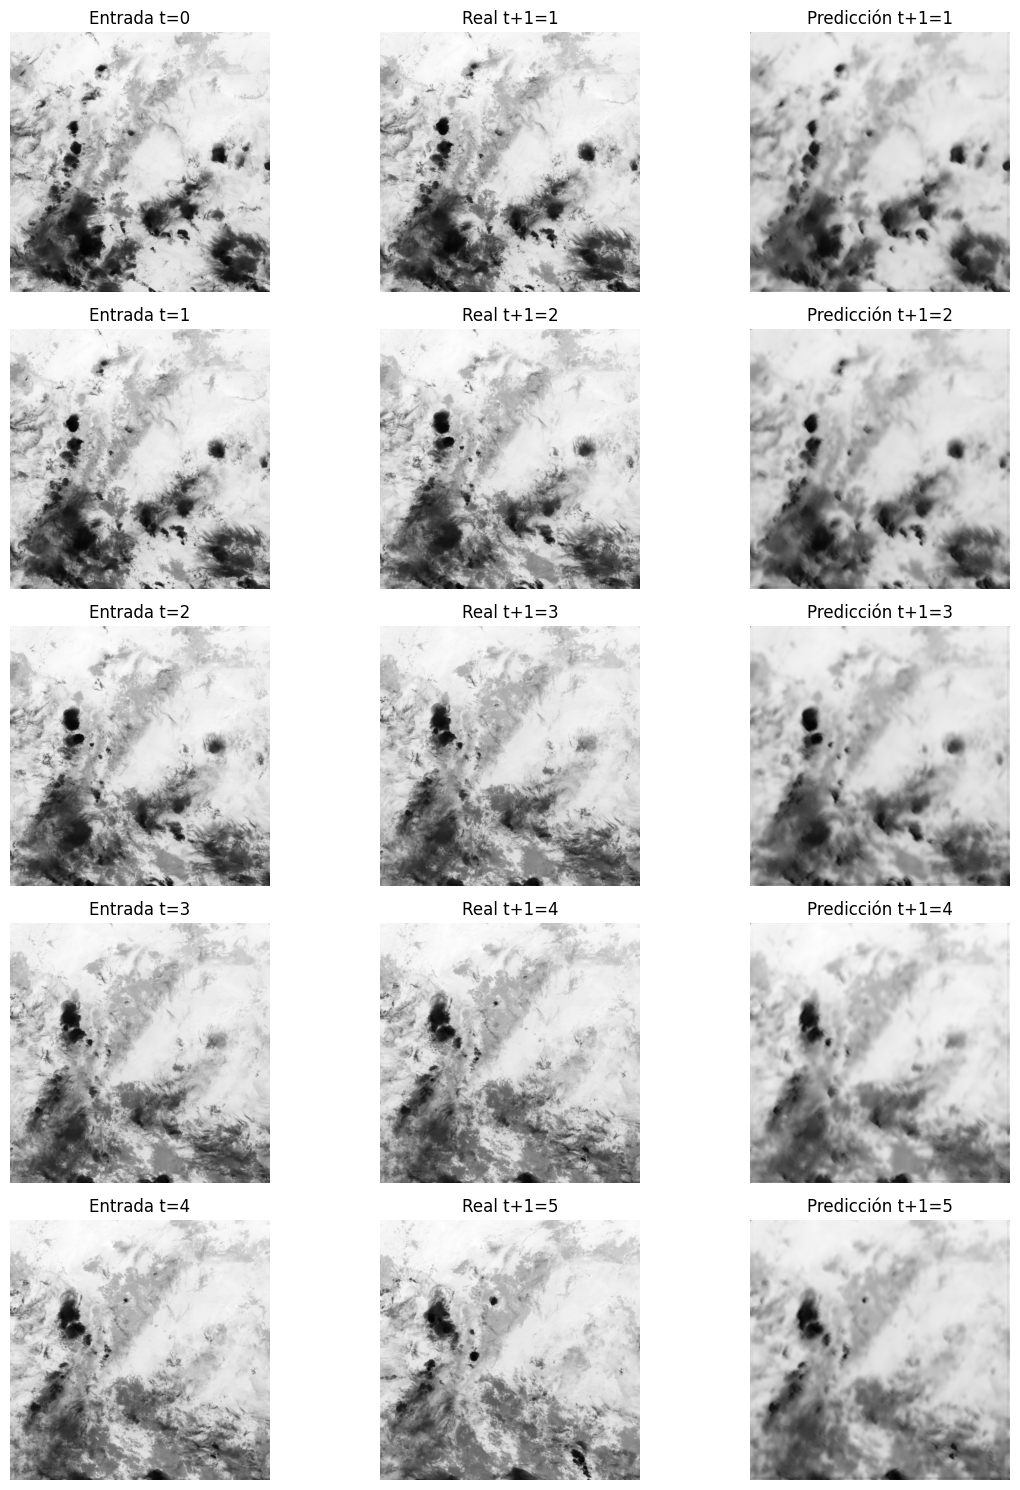

In [5]:
import matplotlib.pyplot as plt

# Generar predicciones
y_pred = model.predict(X)

# Mostrar algunas imágenes reales vs predichas
n = 5  # Número de ejemplos a mostrar
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='gray')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='gray')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred[i, ..., 0], cmap='gray')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar las 23 imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 23 imágenes
Forma de X: (22, 480, 480, 1)
Forma de y: (22, 480, 480, 1)


In [8]:
# Directorio de las nuevas imágenes 920x920 y su destino reducido
d_original_9 = '/home/fisica/bandas/banda9/ene_01'  # Cambia esta ruta por la ubicación real
d_reducida_9 = '/home/fisica/bandas/banda9/ene_01_reducida'  # Cambia esta ruta por el destino deseado

# Redimensionar las imágenes 920x920 a 480x480 usando la función existente
resize_npy_images(d_original_9, d_reducida_9, new_size=(480, 480))

# Cargar las 23 imágenes
file_list = sorted([f for f in os.listdir(d_reducida_9) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_9 = [np.load(os.path.join(d_reducida_9, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_9 = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_9]
images_9 = [np.clip(img, 0, 1) for img in images_9]  # Limita los valores al rango [0, 1]
X_1 = np.array(images_9[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_1 = np.array(images_9[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal


Procesando 23 imágenes


In [10]:
X_multi = np.concatenate([X, X_1], axis=-1)  # (n, 480, 480, 2)
y_multi = np.concatenate([y, y_1], axis=-1)  # (n, 480, 480, 2)

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X_multi.shape[1:]),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (3, 3), activation='linear', padding='same')
])

# model = Sequential([
#     Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
#     Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
#     Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
#     Conv2D(1, kernel_size=(3, 3), activation='linear', padding='same')
# ])

model.compile(optimizer='adam', loss='mae', metrics=['mae'])

print("Resumen del modelo:")
model.summary()

# Entrenamiento rápido - solo 3 épocas
print("Iniciando entrenamiento de prueba...")

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_multi, y_multi,
    epochs=10,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history.history['loss'][-1]:.4f}")



Resumen del modelo:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 480, 480, 16)   │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 480, 480, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,673 (182.32 KB)

 Trainable params: 46,673 (182.32 KB)

 Non-trainable params: 0 (0.00 B)

Iniciando entrenamiento de prueba...
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 10s/step - loss: 0.5086 - mae: 0.5086
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 10s/step - loss: 0.1927 - mae: 0.1927
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 10s/step - loss: 0.1936 - mae: 0.1936
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 10s/step - loss: 0.1447 - mae: 0.1447
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 10s/step - loss: 0.1462 - mae: 0.1462
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 10s/step - loss: 0.1152 - mae: 0.1152
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 10s/step - loss: 0.1080 - mae: 0.1080
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 10s/step - loss: 0.1116 - mae: 0.1116
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 11s/step - loss: 0.1007 - mae: 0.1007
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 10s/step - loss: 0.0997 - mae: 0.0997
¡Prueba completada!
Pérdida final: 0.0997


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


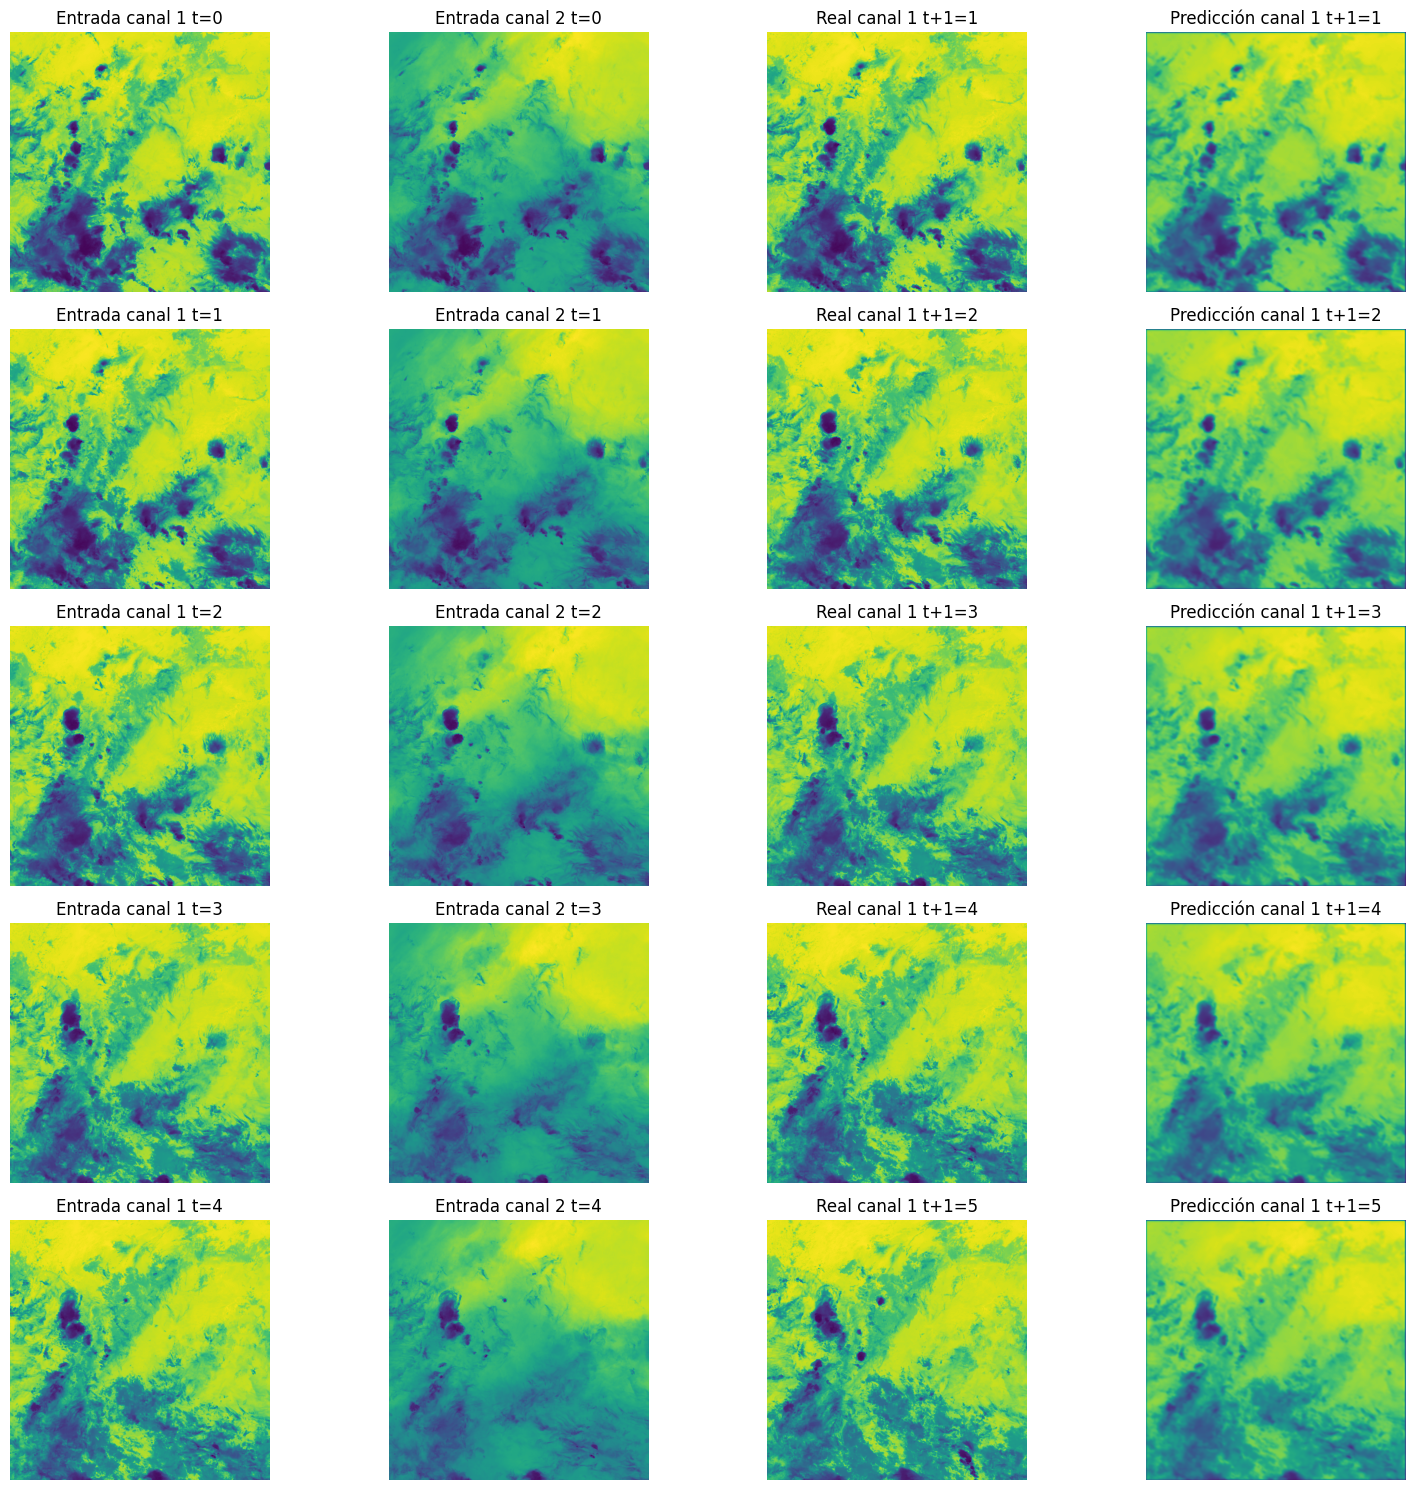

In [12]:
import matplotlib.pyplot as plt

# Generar predicciones con el modelo entrenado
y_pred = model.predict(X_multi)

# Número de ejemplos a mostrar
n = 5

fig, axs = plt.subplots(n, 4, figsize=(16, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X_multi[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada canal 1 t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(X_multi[i, ..., 1], cmap='viridis')
    axs[i, 1].set_title(f'Entrada canal 2 t={i}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_multi[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Real canal 1 t+1={i+1}')
    axs[i, 2].axis('off')

    axs[i, 3].imshow(y_pred[i, ..., 0], cmap='viridis')
    axs[i, 3].set_title(f'Predicción canal 1 t+1={i+1}')
    axs[i, 3].axis('off')

plt.tight_layout()
plt.show()